In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
flood_data = pd.read_csv('/content/FloodPrediction.csv')

In [ ]:
print(flood_data.head())
print(flood_data.info())
print(flood_data.describe())

   Sl Station_Names  Year  Month  Max_Temp  Min_Temp  Rainfall  \
0   0       Barisal  1949      1      29.4      12.3       0.0   
1   1       Barisal  1949      2      33.9      15.2       9.0   
2   2       Barisal  1949      3      36.7      20.2       8.0   
3   3       Barisal  1949      4      33.9      23.9     140.0   
4   4       Barisal  1949      5      35.6      25.0     217.0   

   Relative_Humidity  Wind_Speed  Cloud_Coverage  Bright_Sunshine  \
0               68.0    0.453704             0.6         7.831915   
1               63.0    0.659259             0.9         8.314894   
2               59.0    1.085185             1.5         8.131915   
3               71.0    1.772222             3.9         8.219149   
4               76.0    1.703704             4.1         7.046809   

   Station_Number     X_COR     Y_COR  LATITUDE  LONGITUDE  ALT   Period  \
0           41950  536809.8  510151.9      22.7      90.36    4  1949.01   
1           41950  536809.8  510151.

In [ ]:
flood_data_cleaned = flood_data.copy()

In [ ]:
print("NaN values in 'Flood?':", flood_data['Flood?'].isna().sum())
flood_data_cleaned = flood_data_cleaned.fillna(0)
print("Data shape after cleaning:", flood_data_cleaned.shape)
print("NaN values in 'Flood?' after replacing:", flood_data_cleaned['Flood?'].isna().sum())

NaN values in 'Flood?': 16051
Data shape after cleaning: (20544, 19)
NaN values in 'Flood?' after replacing: 0


In [ ]:
flood_data_cleaned.head()

,Sl,Station_Names,Year,Month,Max_Temp,Min_Temp,Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,Bright_Sunshine,Station_Number,X_COR,Y_COR,LATITUDE,LONGITUDE,ALT,Period,Flood?
0,0,Barisal,1949,1,29.4,12.3,0.0,68.0,0.453704,0.6,7.831915,41950,536809.8,510151.9,22.7,90.36,4,1949.01,0.0
1,1,Barisal,1949,2,33.9,15.2,9.0,63.0,0.659259,0.9,8.314894,41950,536809.8,510151.9,22.7,90.36,4,1949.02,0.0
2,2,Barisal,1949,3,36.7,20.2,8.0,59.0,1.085185,1.5,8.131915,41950,536809.8,510151.9,22.7,90.36,4,1949.03,0.0
3,3,Barisal,1949,4,33.9,23.9,140.0,71.0,1.772222,3.9,8.219149,41950,536809.8,510151.9,22.7,90.36,4,1949.04,0.0
4,4,Barisal,1949,5,35.6,25.0,217.0,76.0,1.703704,4.1,7.046809,41950,536809.8,510151.9,22.7,90.36,4,1949.05,0.0


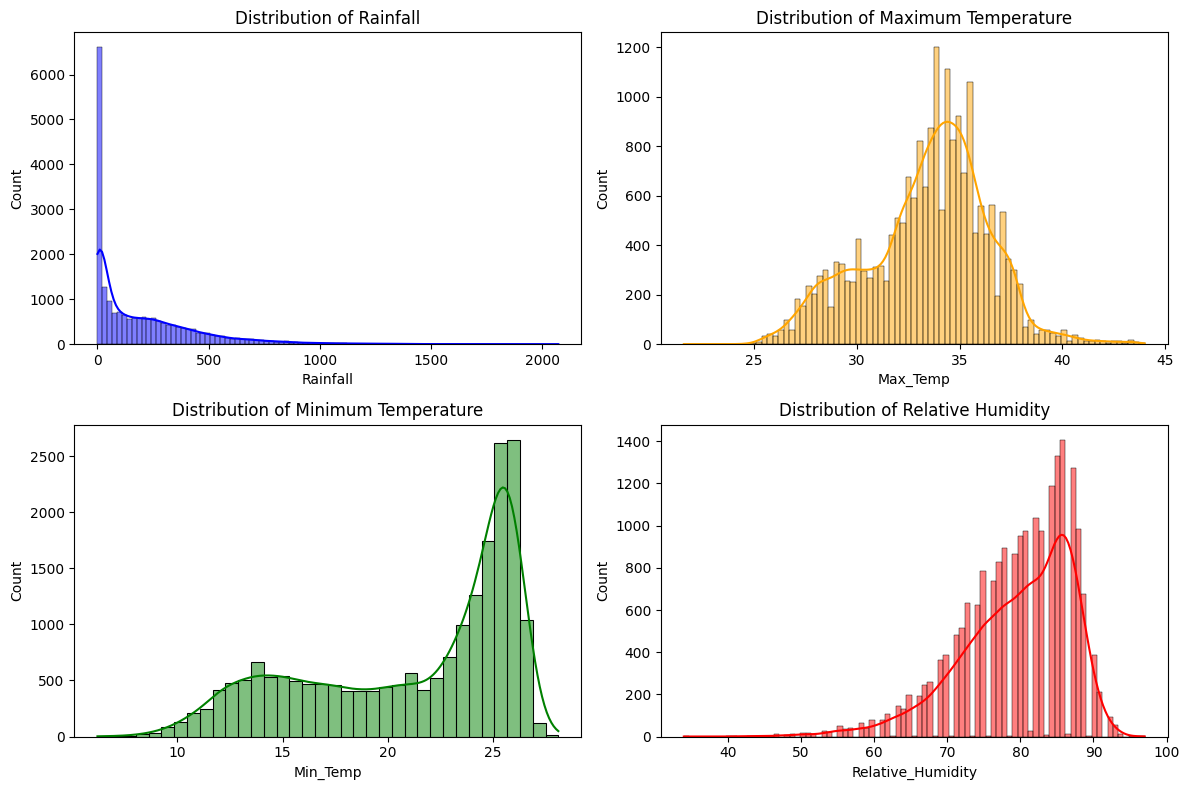

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(flood_data_cleaned['Rainfall'], kde=True, color='blue')
plt.title('Distribution of Rainfall')

plt.subplot(2, 2, 2)
sns.histplot(flood_data_cleaned['Max_Temp'], kde=True, color='orange')
plt.title('Distribution of Maximum Temperature')

plt.subplot(2, 2, 3)
sns.histplot(flood_data_cleaned['Min_Temp'], kde=True, color='green')
plt.title('Distribution of Minimum Temperature')

plt.subplot(2, 2, 4)
sns.histplot(flood_data_cleaned['Relative_Humidity'], kde=True, color='red')
plt.title('Distribution of Relative Humidity')

plt.tight_layout()
plt.show()

## **Feature** **Engineering**






In [ ]:
flood_data_cleaned['Temp_Diff'] = flood_data_cleaned['Max_Temp'] - flood_data_cleaned['Min_Temp']
flood_data_cleaned['Rainfall_Squared'] = flood_data_cleaned['Rainfall'] ** 2

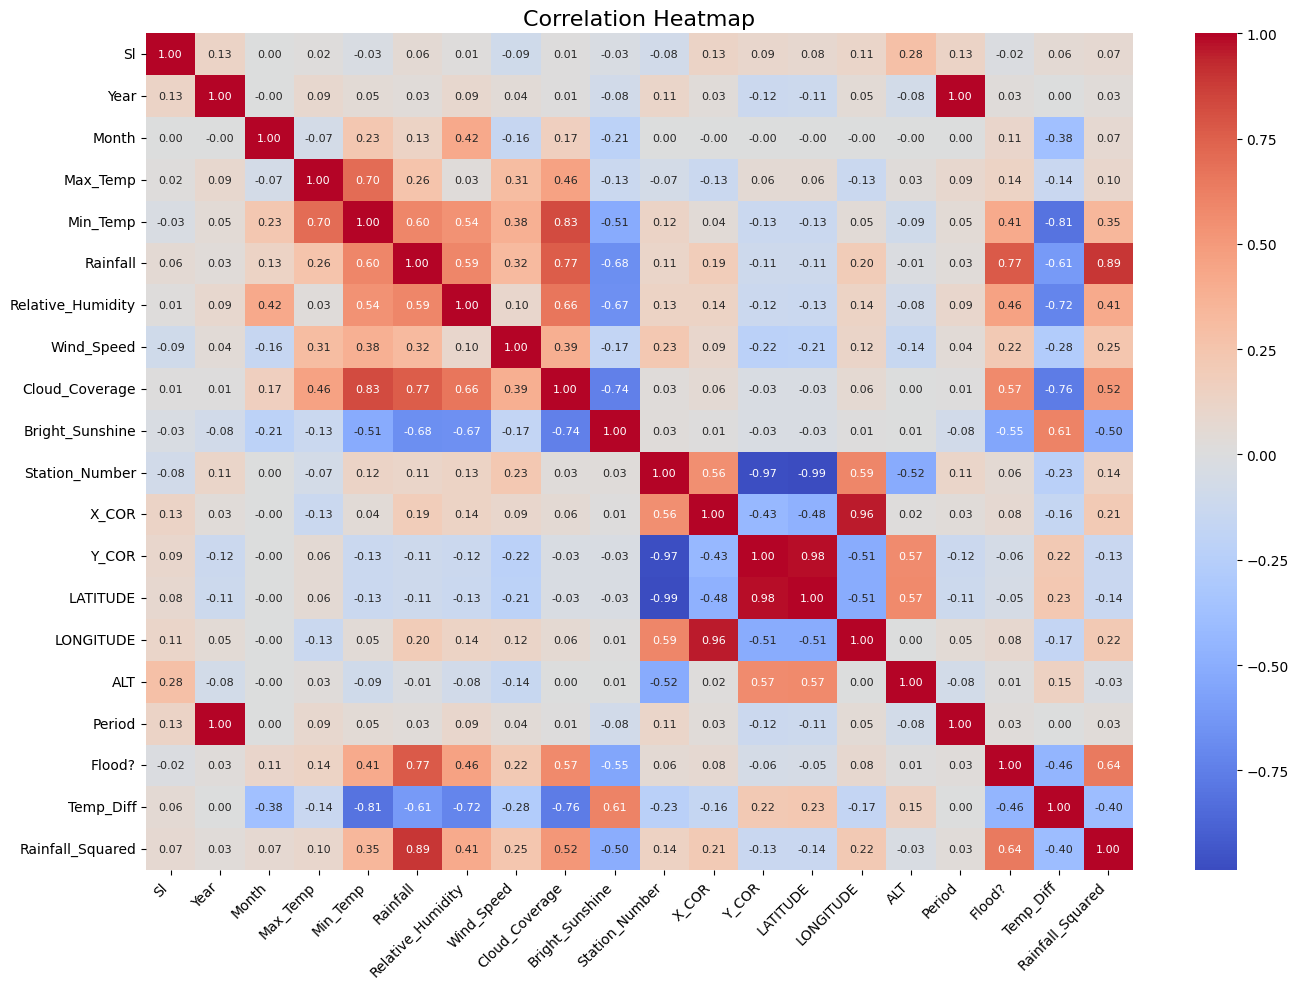

In [ ]:

numerical_data = flood_data_cleaned.select_dtypes(include=['number'])

plt.figure(figsize=(14, 10))

correlation_matrix = numerical_data.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 8})

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
X = flood_data_cleaned[['Max_Temp', 'Min_Temp', 'Rainfall', 'Relative_Humidity', 'Wind_Speed', 'Cloud_Coverage', 'Bright_Sunshine', 'Temp_Diff', 'Rainfall_Squared']]
y = flood_data_cleaned['Flood?']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Define the 9 feature column names
X_train_columns = [
    'Max_Temp', 'Min_Temp', 'Rainfall', 'Relative_Humidity',
    'Wind_Speed', 'Cloud_Coverage', 'Bright_Sunshine', 'Temp_Diff', 'Rainfall_Squared'
]

# Ensure X_train_scaled has the same number of features (9)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_columns)

# Display the DataFrame to confirm it has 9 columns
X_train_scaled_df.head()

,Max_Temp,Min_Temp,Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,Bright_Sunshine,Temp_Diff,Rainfall_Squared
0,-0.418228,1.022198,0.328876,0.980890,0.184632,1.067475,-1.177659,-1.759034,-0.092619
1,-0.182240,0.759552,0.416320,0.980890,-0.779628,0.875391,-0.841558,-1.200616,-0.037135
2,-0.418228,0.961587,0.932655,0.719544,-0.490350,1.163516,-1.220691,-1.675271,0.373105
3,0.896561,0.052426,-0.695467,-1.371224,0.473910,-0.373150,0.830741,0.670085,-0.440771
4,-0.283378,0.416091,-0.687139,0.588871,-0.297498,-0.613254,0.899682,-0.809723,-0.440183


In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"---{model_name}---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred))
    plot_confusion_matrix(y_true, y_pred, model_name)

In [ ]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression()

---Logistic Regression---
Accuracy: 0.9406
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96      3300
         1.0       0.86      0.83      0.85       809

    accuracy                           0.94      4109
   macro avg       0.91      0.90      0.90      4109
weighted avg       0.94      0.94      0.94      4109



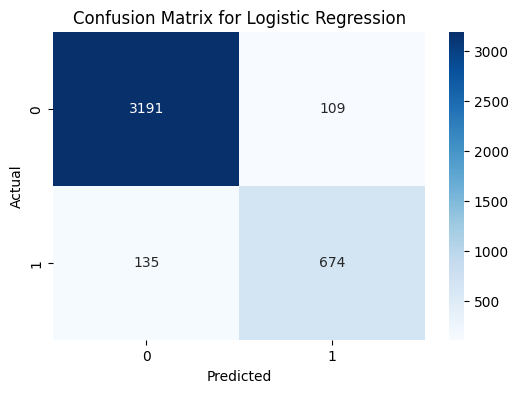

In [ ]:
y_pred_logistic = logistic_model.predict(X_test_scaled)
evaluate_model(y_test, y_pred_logistic, "Logistic Regression")

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

---Random Forest---
Accuracy: 0.9448
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97      3300
         1.0       0.87      0.84      0.86       809

    accuracy                           0.94      4109
   macro avg       0.92      0.91      0.91      4109
weighted avg       0.94      0.94      0.94      4109



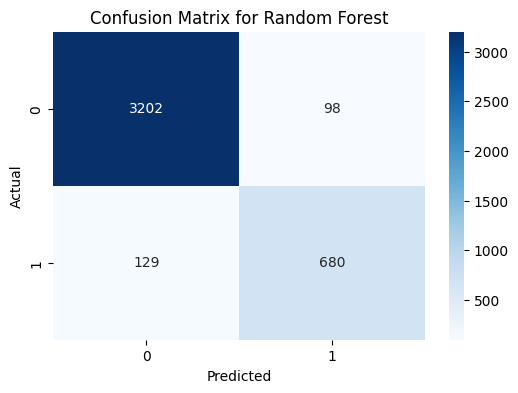

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)
evaluate_model(y_test, y_pred_rf, "Random Forest")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Define the features as per your training data
feature_columns = [
    'Max_Temp', 'Min_Temp', 'Rainfall', 'Relative_Humidity',
    'Wind_Speed', 'Cloud_Coverage', 'Bright_Sunshine', 'Temp_Diff', 'Rainfall_Squared'
]

# Generate random values or input specific values for prediction
# For random values:
random_data = np.random.rand(1, len(feature_columns))

# Create a DataFrame with random values for the input
input_data = pd.DataFrame(random_data, columns=feature_columns)

# Scale the data if needed (assuming you have a scaler)
# Uncomment if a scaler was used during training
# scaler = StandardScaler()
# input_data_scaled = scaler.transform(input_data)

# Predict using the model (scaled or unscaled based on model requirements)
y_pred_random = rf_model.predict(input_data)  # Change to input_data_scaled if scaling is applied

print("Prediction for new random data:", y_pred_random)

Prediction for new random data: [0.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

---Support Vector Machine (SVM)---
Accuracy: 0.9428
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96      3300
         1.0       0.88      0.82      0.85       809

    accuracy                           0.94      4109
   macro avg       0.92      0.90      0.91      4109
weighted avg       0.94      0.94      0.94      4109



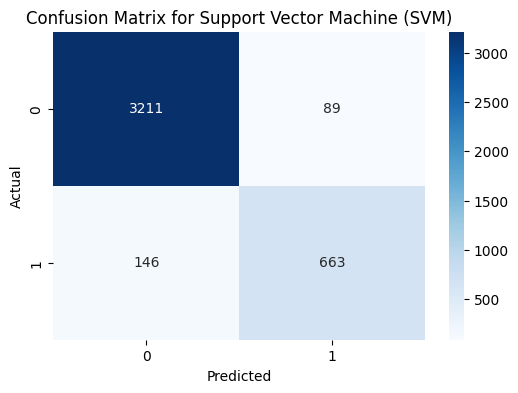

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)
evaluate_model(y_test, y_pred_svm, "Support Vector Machine (SVM)")

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

---K-Nearest Neighbors (KNN)---
Accuracy: 0.9377
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96      3300
         1.0       0.85      0.83      0.84       809

    accuracy                           0.94      4109
   macro avg       0.90      0.90      0.90      4109
weighted avg       0.94      0.94      0.94      4109



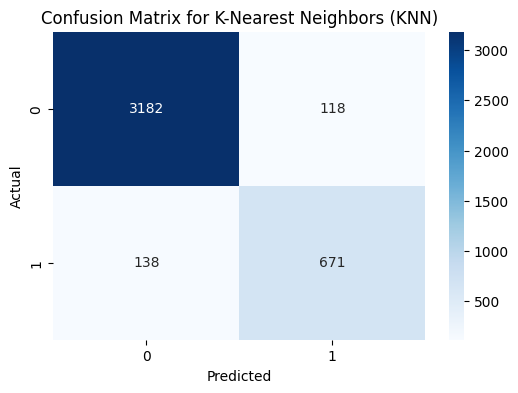

In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled)
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")

In [ ]:
models = ['Logistic Regression', 'Random Forest', 'SVM', 'KNN']
accuracies = [accuracy_score(y_test, y_pred_logistic),
              accuracy_score(y_test, y_pred_rf),
              accuracy_score(y_test, y_pred_svm),
              accuracy_score(y_test, y_pred_knn)]

/tmp/ipykernel_9599/2215263486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=models, y=accuracies, palette='coolwarm')


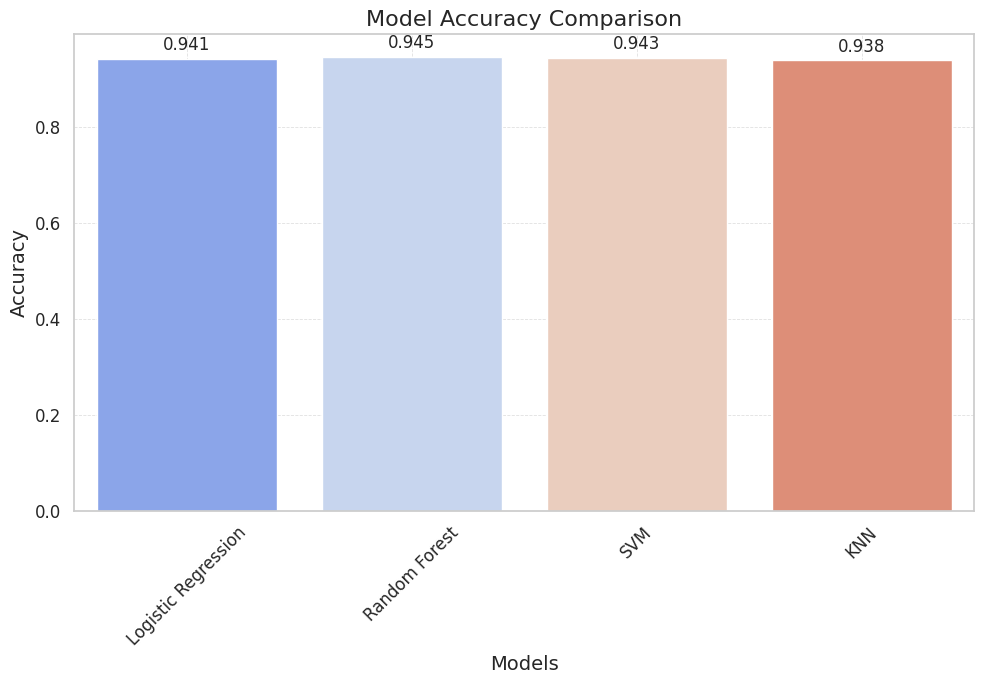

In [ ]:
plt.figure(figsize=(10, 7))
sns.set(style="whitegrid")
bar = sns.barplot(x=models, y=accuracies, palette='coolwarm')

for p in bar.patches:
    bar.text(p.get_x() + p.get_width() / 2., p.get_height() + 0.01, f'{p.get_height():.3f}', ha="center", va='bottom')

plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
risk_categories = []
for prob in y_prob_rf:
    if prob > 0.75:
        risk_categories.append('High Risk')
    elif 0.25 < prob <= 0.75:
        risk_categories.append('Medium Risk')
    else:
        risk_categories.append('Low Risk')

In [ ]:
X_test_original = X_test.reset_index(drop=True)

original_indices = X_test.index

districts = flood_data_cleaned.loc[X_test.index, 'Station_Names'].reset_index(drop=True)

In [ ]:
risk_df = pd.DataFrame({
    'Station_Name': districts,
    'Predicted_Probability': y_prob_rf,
    'Risk_Level': risk_categories
})

In [ ]:
print(risk_df)

                  Station_Name  Predicted_Probability Risk_Level
0                      Barisal                   0.00   Low Risk
1                       Hatiya                   0.00   Low Risk
2                      Ishurdi                   0.00   Low Risk
3                       Mongla                   0.05   Low Risk
4                      Comilla                   0.00   Low Risk
...                        ...                    ...        ...
4104                  Satkhira                   0.20   Low Risk
4105  Chittagong (IAP-Patenga)                   0.00   Low Risk
4106                Mymensingh                   0.00   Low Risk
4107                Mymensingh                   0.10   Low Risk
4108                     Dhaka                   0.21   Low Risk

[4109 rows x 3 columns]


/tmp/ipykernel_9599/1113551379.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=risk_df, x='Risk_Level', palette='coolwarm', order=['Low Risk', 'Medium Risk', 'High Risk'])


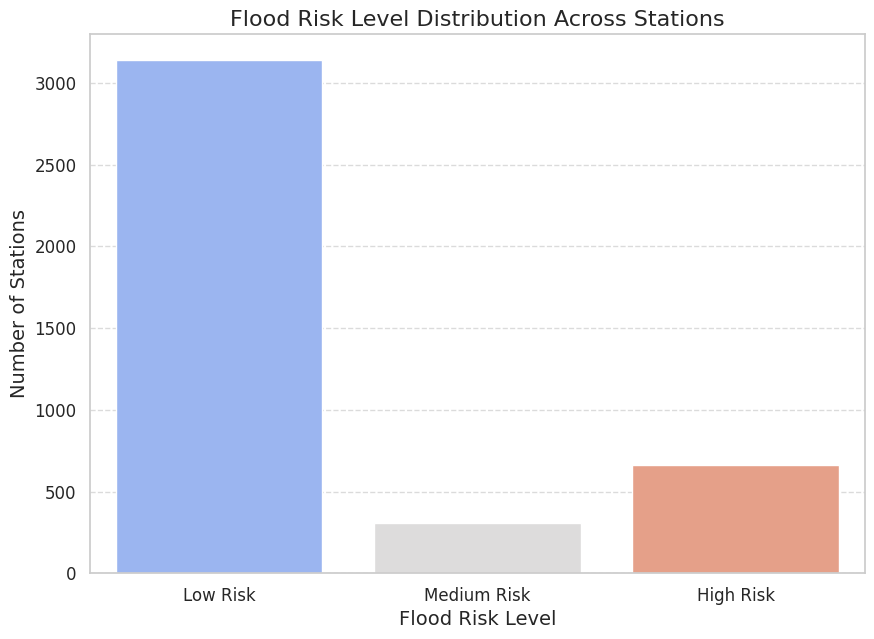

In [ ]:
plt.figure(figsize=(10, 7))
sns.countplot(data=risk_df, x='Risk_Level', palette='coolwarm', order=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Flood Risk Level Distribution Across Stations', fontsize=16)
plt.xlabel('Flood Risk Level', fontsize=14)
plt.ylabel('Number of Stations', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

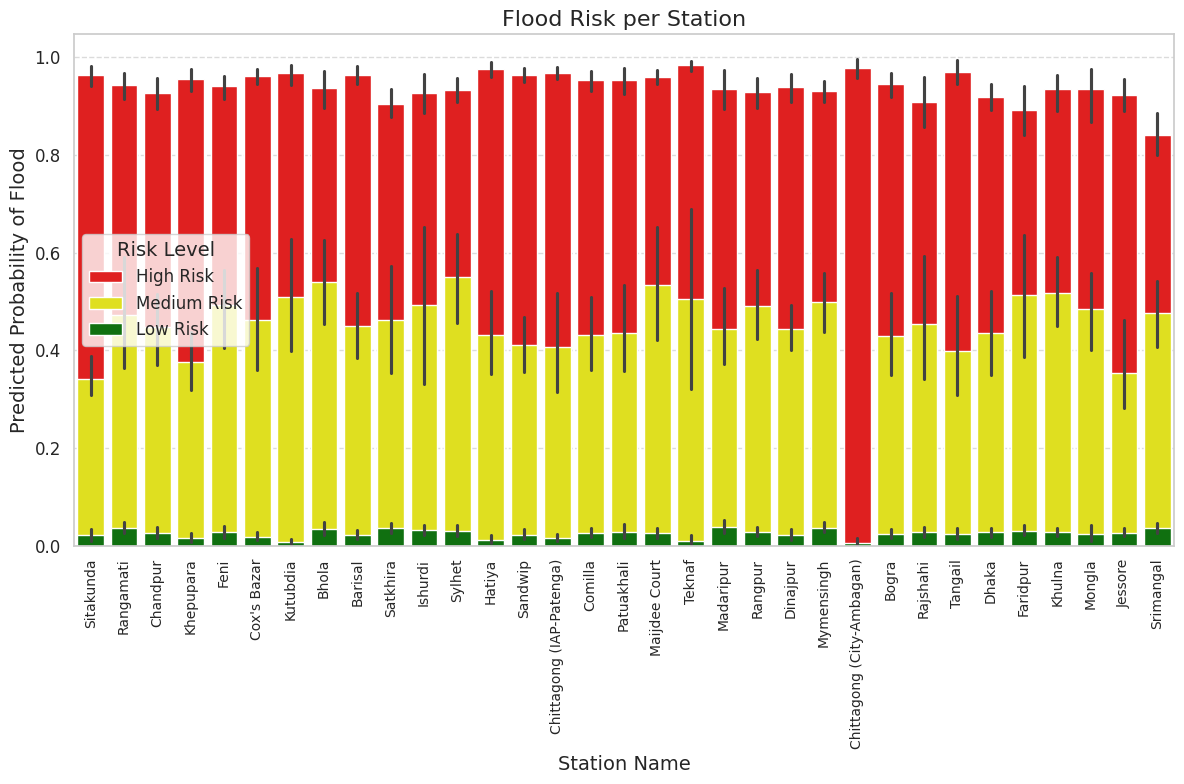

In [ ]:
plt.figure(figsize=(12, 8))

palette = {
    'Low Risk': 'green',
    'Medium Risk': 'yellow',
    'High Risk': 'red'
}

sns.barplot(data=risk_df.sort_values('Predicted_Probability', ascending=False),
            x='Station_Name',
            y='Predicted_Probability',
            hue='Risk_Level',
            dodge=False,
            palette=palette)

plt.title('Flood Risk per Station', fontsize=16)
plt.xlabel('Station Name', fontsize=14)
plt.ylabel('Predicted Probability of Flood', fontsize=14)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=12)

plt.legend(title='Risk Level', fontsize=12, title_fontsize=14)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

In [ ]:
X_test_original = X_test.reset_index(drop=True)
districts = flood_data_cleaned['Station_Names'].iloc[X_test.index].reset_index(drop=True)


In [ ]:
risk_df = pd.DataFrame({
    'Station_Name': districts,
    'Predicted_Probability': y_prob_rf,
    'Risk_Level': risk_categories,
    'Month': flood_data_cleaned['Month'].iloc[X_test.index].reset_index(drop=True)
})

In [ ]:
print(risk_df.head())

  Station_Name  Predicted_Probability Risk_Level  Month
0      Barisal                   0.00   Low Risk      2
1       Hatiya                   0.00   Low Risk      5
2      Ishurdi                   0.00   Low Risk      2
3       Mongla                   0.05   Low Risk     10
4      Comilla                   0.00   Low Risk      1


In [ ]:
monthly_station_risk = risk_df.groupby(['Month', 'Station_Name']).agg({'Predicted_Probability': 'mean'}).reset_index()

In [ ]:
pivot_risk = monthly_station_risk.pivot(index="Station_Name", columns="Month", values="Predicted_Probability").fillna(0)


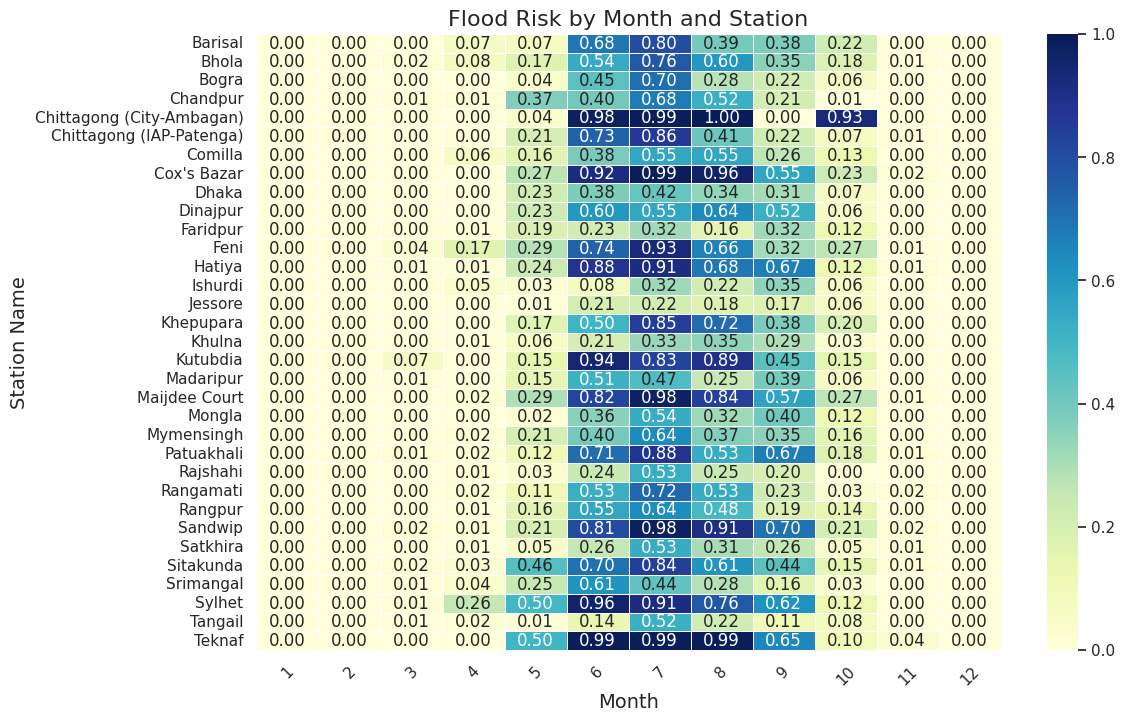

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_risk, cmap='YlGnBu', annot=True, fmt='.2f', linewidths=.5)
plt.title('Flood Risk by Month and Station', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Station Name', fontsize=14)
plt.xticks(rotation=45)
plt.show()

In [ ]:
import joblib
joblib.dump(rf_model, 'rf_model.pkl')

model_path = 'rf_model.pkl'
model = joblib.load(model_path)

model.predict(X_test)

In [ ]:
from flask import Flask, request, jsonify
import joblib
import threading

# Load your model
model_path = 'rf_model.pkl'
model = joblib.load(model_path)

# Initialize Flask server
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    station_name = data.get('Station_Name')
    month = data.get('Month')

    # Convert inputs to the format your model expects
    input_data = [[station_name, month]]

    # Predict probability (modify based on how your model outputs)
    try:
        probability = model.predict_proba(input_data)[0][1]  # Example for binary classification
        return jsonify({'Predicted_Probability': probability})
    except Exception as e:
        return jsonify({'error': str(e)}), 500

# Function to run Flask app in a separate thread
def run_flask():
    app.run(host='0.0.0.0', port=5050, use_reloader=False)  # Update host

# Start the Flask app in a background thread
flask_thread = threading.Thread(target=run_flask)
flask_thread.start()